# FASTMIP Phase 2 – Multi-model comparison
Reproduces all plots from `tour_through_requested_output.ipynb` for three
emulators (**RIME-X**, **meteor**, **MESMER**) shown side-by-side.


In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import regionmask
from pathlib import Path


In [ ]:
# ── Scenarios of interest ───────────────────────────────────────────────
# Shared scenario keys used everywhere in this notebook.
# Each model entry maps these keys to its own folder/file naming convention.
SCENARIOS = ["VL", "L", "M", "H"]
sel_scenario = "H"   # scenario used for single-scenario plots
sel_model = 'CanESM5'
# ── Model definitions ───────────────────────────────────────────────
# scen_map : shared key → folder name used by this model
# file_scen: shared key → scenario token used inside the file name
#            (if None, defaults to the folder name)
MODELS = [
    {
        "name":      "RIME-X",
        "root":      Path("/path/to/fastmip"),
        "base_path": lambda root: root / "RIME-X" / "tas",
        "scen_map":  {"VL": "VL", "L": "L", "M": "M", "H": "H"},
        "esm_dim":       "esm_calibration",
        "esm_val":       sel_model.lower(),
        "esm_val_across": "primary-and-secondary",  # version selector for across-ESM files
        "region_dim":    "region",
        "var_glob": "var_glob"
    },
    {
        "name":      "meteor",
        "root":      Path("/path/to/fastmip"),
        "base_path": lambda root: root / "meteor" / "tas",
        "scen_map":  {"VL": "VL", "L": "L", "M": "M", "H": "H"},
        "esm_dim":      "esm",
        "esm_val":      sel_model,
        "region_dim":   "mask",
        "var_glob": "var_global"
    },
    {
        "name":      "MESMER",
        "root":      Path("/path/to/mesmer"),
        "base_path": lambda root: root,
        # MESMER uses the full SSP string for both folder and file name
        "scen_map":  {"VL": "SSP1-VL", "L": "SSP2-L", "M": "SSP2-M", "H": "SSP3-H"},
        "esm_dim":      "mesmer_esm_calibration",
        "esm_val":      sel_model,
        "region_dim":   "mask",
        "var_glob": "var_glob"
    },
]
_ar6 = regionmask.defined_regions.ar6.land
_int_to_abbrev = {r.number: r.abbrev for r in _ar6} | {-1: "GLOBAL"}
_int_to_int    = {r.number: r.number for r in _ar6} | {-1: -1}
for _m in MODELS:
    if _m["region_dim"] == "region":   # RIME-X
        _m["region_vals"] = _int_to_abbrev
    else:                              # meteor, MESMER
        _m["region_vals"] = _int_to_int

def model_path(m, scen):
    """Return the scenario sub-folder Path for model m and shared scenario key."""
    return m["base_path"](m["root"]) / m["scen_map"][scen]

def file_scen_token(m, scen):
    """Return the scenario token used inside the file name."""
    return m["scen_map"][scen]

sel_lat  = 46.25   # France
sel_lon  = 3.75

selected_regions = [-1, 34, 17]   # global, Tibetan Plateau, W-Central Europe

YEAR_START = 2020
YEAR_END   = 2100

def filter_years(ds_or_da):
    """Slice any dataset/dataarray to YEAR_START–YEAR_END on the 'year' dimension."""
    return ds_or_da.sel(year=slice(YEAR_START, YEAR_END))

def fname(scen_token, model_name, aggregation, quantity):
    return f"tas_{scen_token}_{model_name}_{aggregation}_{quantity}.nc"

def cross_fname(model_name, aggregation, quantity):
    return f"tas_cross-scenario_{model_name}_{aggregation}_{quantity}.nc"

def sel1d(da, model=None, **kwargs):
    result = da.sel(**kwargs).squeeze()
    extra = [d for d in result.dims if d != "year"]
    for dim in extra:
        if model is not None and dim == model.get("esm_dim") and "esm_val_across" in model:
            result = result.sel({dim: model["esm_val_across"]})
        else:
            result = result.mean(dim=dim)
    return result.values


## 1. Sample realisations

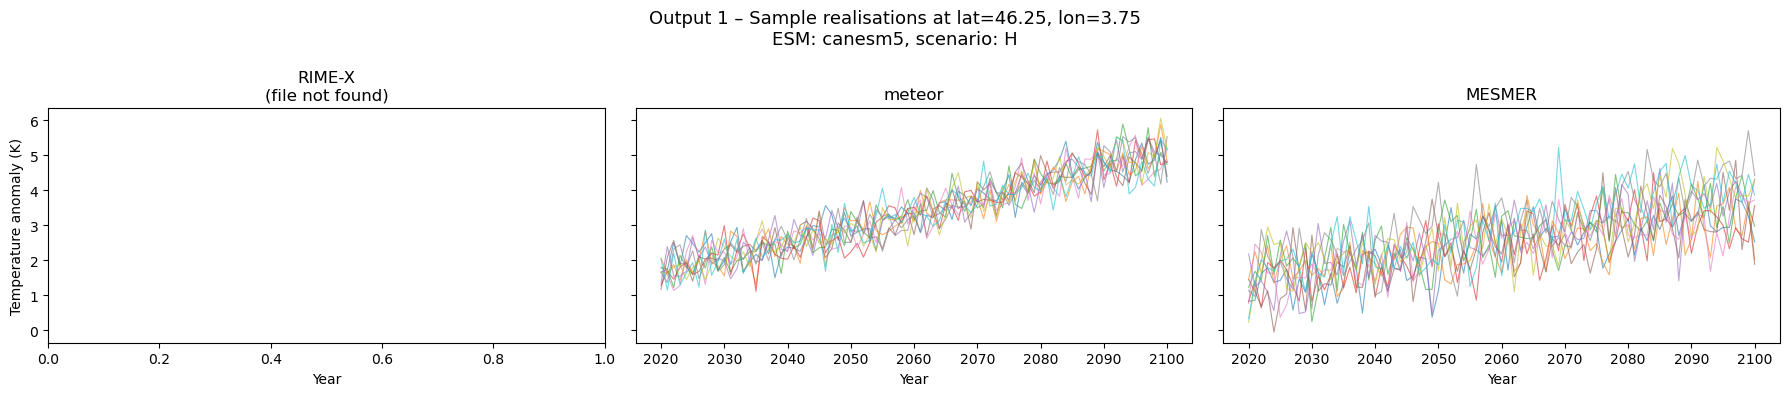

In [6]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "gridcell", "selected-realisations")
    try:
        tas = filter_years(xr.open_dataarray(f))
        sel = tas.sel(lat=sel_lat, lon=sel_lon)
        # handle either mesmer_esm_calibration or esm_calibration dim
        if m["esm_dim"] in sel.dims:
            sel = sel.sel({m["esm_dim"]: m["esm_val"]})
        real_dim = [d for d in sel.dims if d != "year"][0]
        sel = sel.transpose("year", real_dim)
        # sel dims are (realisation, year); transpose to (year, realisation) for matplotlib
        ax.plot(tas["year"].values, sel.values, alpha=0.6, lw=0.8)
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Temperature anomaly (K)")
fig.suptitle(
    f"Output 1 – Sample realisations at lat={sel_lat}, lon={sel_lon}\n"
    f"ESM: {MODELS[0]['esm_val']}, scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()


## 2. Gridcell quantiles by ESM

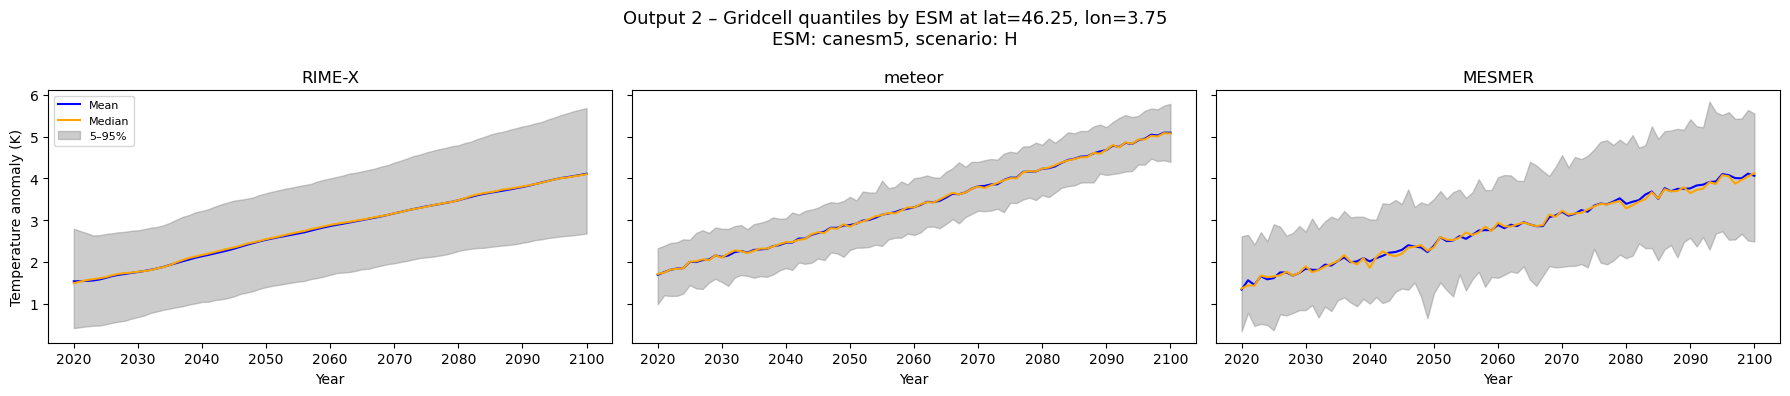

In [7]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "gridcell", "quantiles-by-ESM")
    try:
        ds = filter_years(xr.open_dataset(f))
        kw = {"lat": sel_lat, "lon": sel_lon, m["esm_dim"]: m["esm_val"]}
        mean   = ds["tas_mean"].sel(**kw).values
        median = ds["tas"].sel(quantile=0.5, **kw).values
        lo     = ds["tas"].sel(quantile=0.05, **kw).values
        hi     = ds["tas"].sel(quantile=0.95, **kw).values
        yr     = ds["year"].values
        ax.plot(yr, mean,   color="blue",   label="Mean")
        ax.plot(yr, median, color="orange", label="Median")
        ax.fill_between(yr, lo, hi, color="gray", alpha=0.4, label="5–95%")
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Temperature anomaly (K)")
axes[0].legend(fontsize=8)
fig.suptitle(
    f"Output 2 – Gridcell quantiles by ESM at lat={sel_lat}, lon={sel_lon}\n"
    f"ESM: {MODELS[0]['esm_val']}, scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()


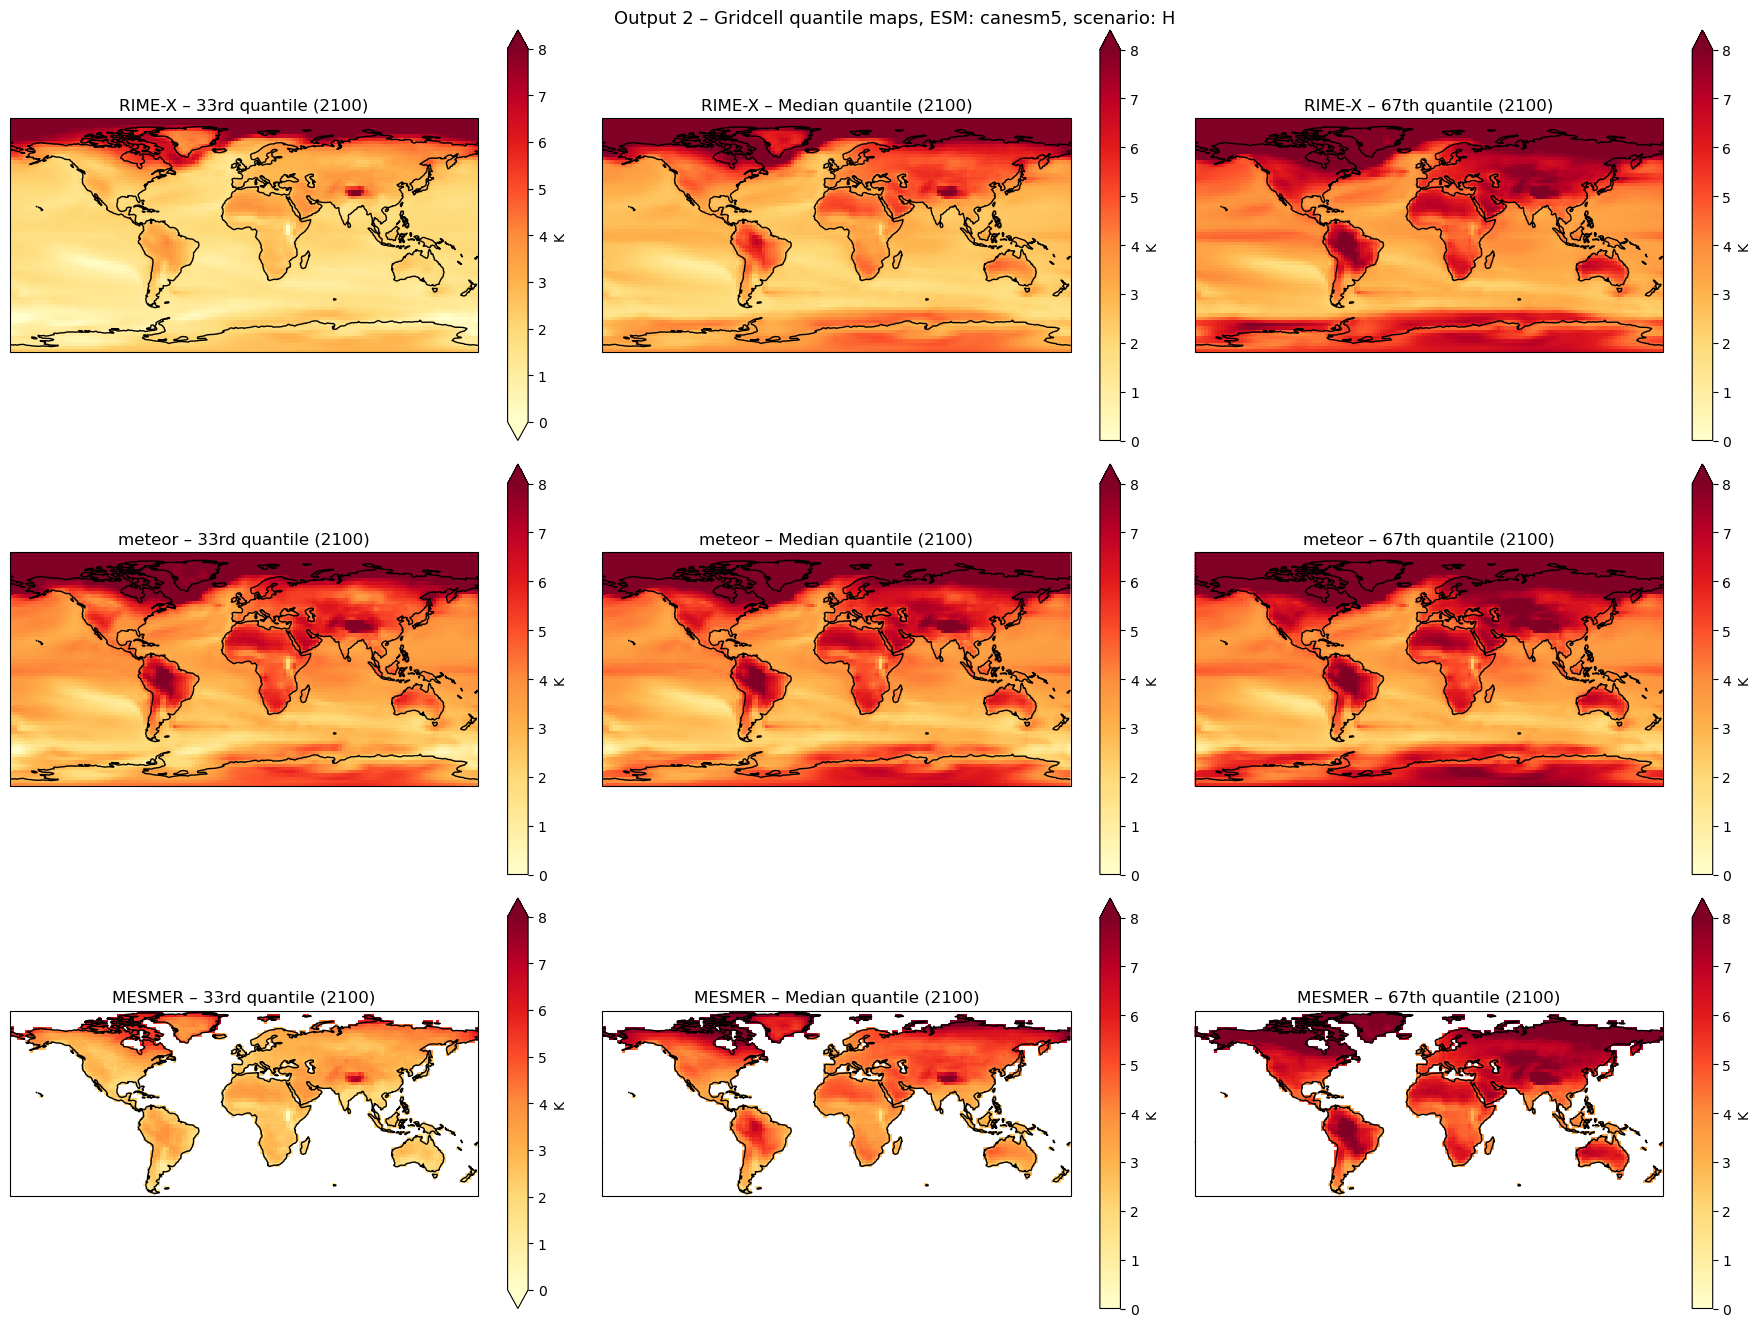

In [8]:
quantiles_to_plot = [0.05, 0.5, 0.95]
qtitles = ["33rd", "Median", "67th"]

fig, axes = plt.subplots(
    len(MODELS), 3,
    figsize=(18, 4.5 * len(MODELS)),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for row, m in enumerate(MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "gridcell", "quantiles-by-ESM")
    try:
        ds = filter_years(xr.open_dataset(f))
        for col, (q, qt) in enumerate(zip(quantiles_to_plot, qtitles)):
            ax = axes[row, col]
            data = ds["tas"].sel(quantile=q, year=2100, **{m["esm_dim"]: m["esm_val"]})
            data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="YlOrRd",
                      vmin=0, vmax=8, cbar_kwargs={"label": "K"})
            ax.coastlines()
            ax.set_title(f"{m['name']} – {qt} quantile (2100)")
    except FileNotFoundError:
        for col in range(3):
            axes[row, col].set_title(f"{m['name']}\n(file not found)")

fig.suptitle(
    f"Output 2 – Gridcell quantile maps, ESM: {MODELS[0]['esm_val']}, scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()


## 3. Gridcell quantiles across ESMs

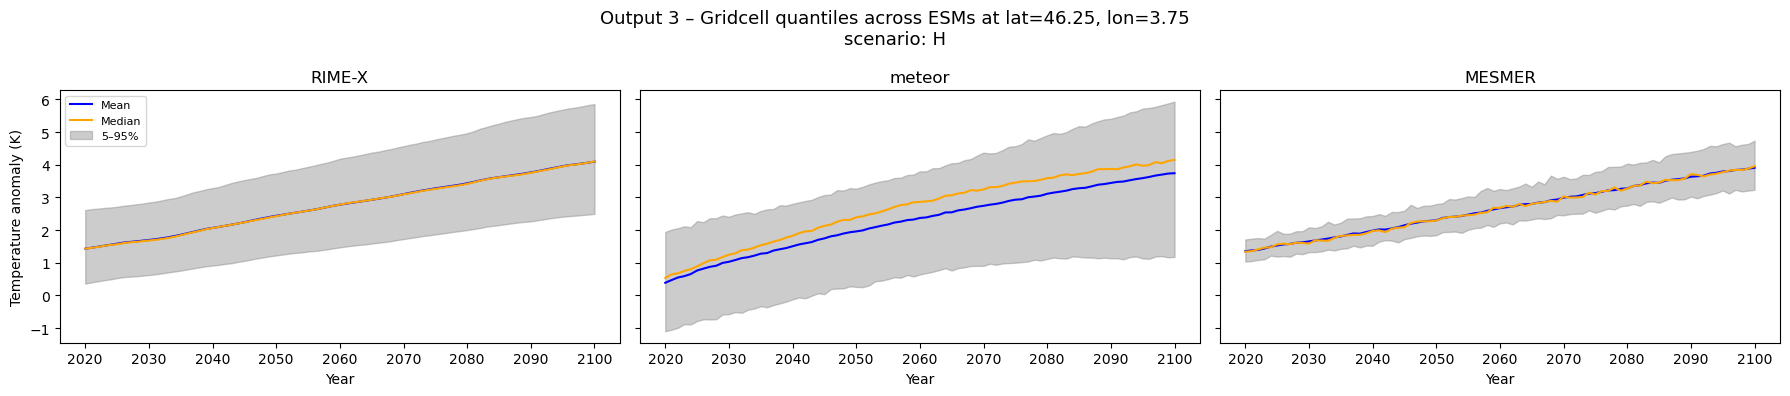

In [9]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "gridcell", "quantiles-across-ESM")
    try:
        ds = filter_years(xr.open_dataset(f))
        kw = {"lat": sel_lat, "lon": sel_lon}
        mean   = sel1d(ds["tas_mean"], **kw)
        median = sel1d(ds["tas"], quantile=0.5, **kw)
        lo     = sel1d(ds["tas"], quantile=0.05, **kw)
        hi     = sel1d(ds["tas"], quantile=0.95, **kw)
        yr     = ds["year"].values
        ax.plot(yr, mean,   color="blue",   label="Mean")
        ax.plot(yr, median, color="orange", label="Median")
        ax.fill_between(yr, lo, hi, color="gray", alpha=0.4, label="5–95%")
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Temperature anomaly (K)")
axes[0].legend(fontsize=8)
fig.suptitle(
    f"Output 3 – Gridcell quantiles across ESMs at lat={sel_lat}, lon={sel_lon}\n"
    f"scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()

## 4. Regional quantiles by ESM

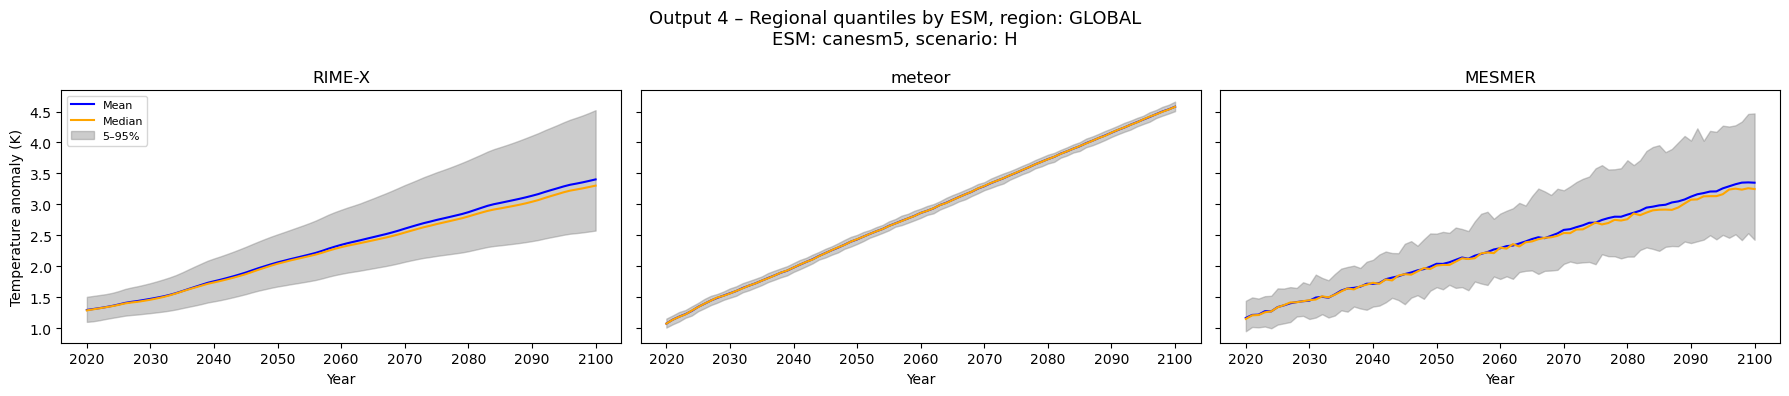

In [10]:
sel_mask = selected_regions[0]
region_name = _int_to_abbrev[sel_mask]

fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "regional", "quantiles-by-ESM")
    try:
        ds = filter_years(xr.open_dataset(f))
        kw = {m["region_dim"]: m["region_vals"][sel_mask], m["esm_dim"]: m["esm_val"]}
        mean   = sel1d(ds["tas_mean"], model=m, **kw)
        median = sel1d(ds["tas"], model=m, quantile=0.5, **kw)
        lo     = sel1d(ds["tas"], model=m, quantile=0.05, **kw)
        hi     = sel1d(ds["tas"], model=m, quantile=0.95, **kw)
        yr     = ds["year"].values
        ax.plot(yr, mean,   color="blue",   label="Mean")
        ax.plot(yr, median, color="orange", label="Median")
        ax.fill_between(yr, lo, hi, color="gray", alpha=0.4, label="5–95%")
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Temperature anomaly (K)")
axes[0].legend(fontsize=8)
fig.suptitle(
    f"Output 4 – Regional quantiles by ESM, region: {region_name}\n"
    f"ESM: {MODELS[0]['esm_val']}, scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()

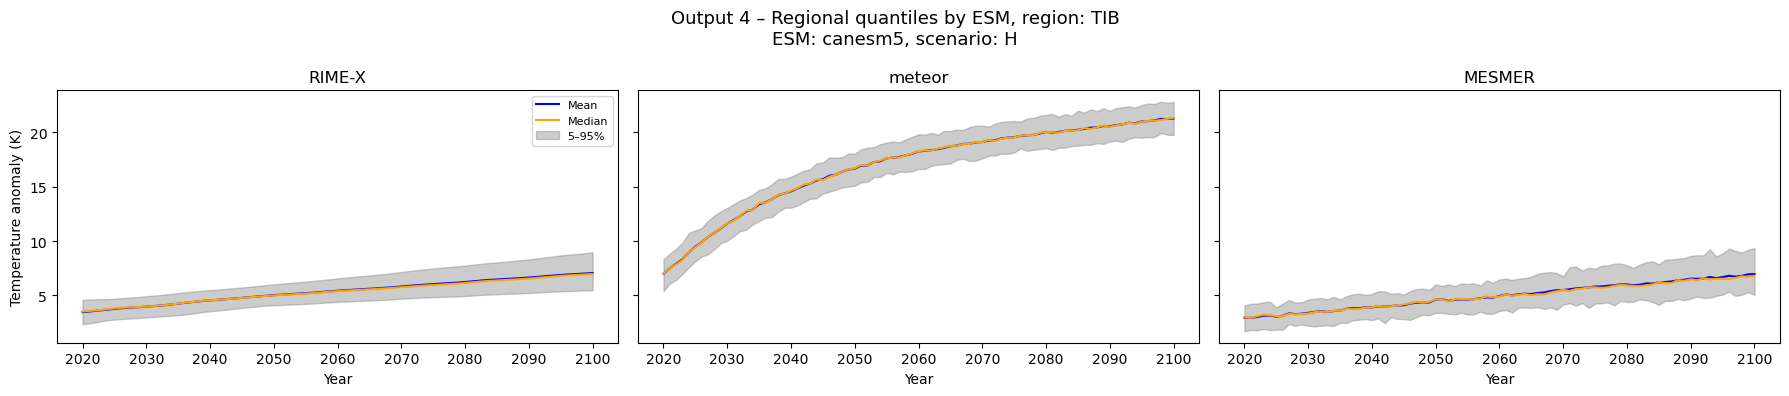

In [11]:
sel_mask = 34 # tibetean plateau
region_name = _int_to_abbrev[sel_mask]

fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "regional", "quantiles-by-ESM")
    try:
        ds = filter_years(xr.open_dataset(f))
        kw = {m["region_dim"]: m["region_vals"][sel_mask], m["esm_dim"]: m["esm_val"]}
        mean   = sel1d(ds["tas_mean"], model=m, **kw)
        median = sel1d(ds["tas"], model=m, quantile=0.5, **kw)
        lo     = sel1d(ds["tas"], model=m, quantile=0.05, **kw)
        hi     = sel1d(ds["tas"], model=m, quantile=0.95, **kw)
        yr     = ds["year"].values
        ax.plot(yr, mean,   color="blue",   label="Mean")
        ax.plot(yr, median, color="orange", label="Median")
        ax.fill_between(yr, lo, hi, color="gray", alpha=0.4, label="5–95%")
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Temperature anomaly (K)")
axes[0].legend(fontsize=8)
fig.suptitle(
    f"Output 4 – Regional quantiles by ESM, region: {region_name}\n"
    f"ESM: {MODELS[0]['esm_val']}, scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()

## 5. Regional quantiles across ESMs

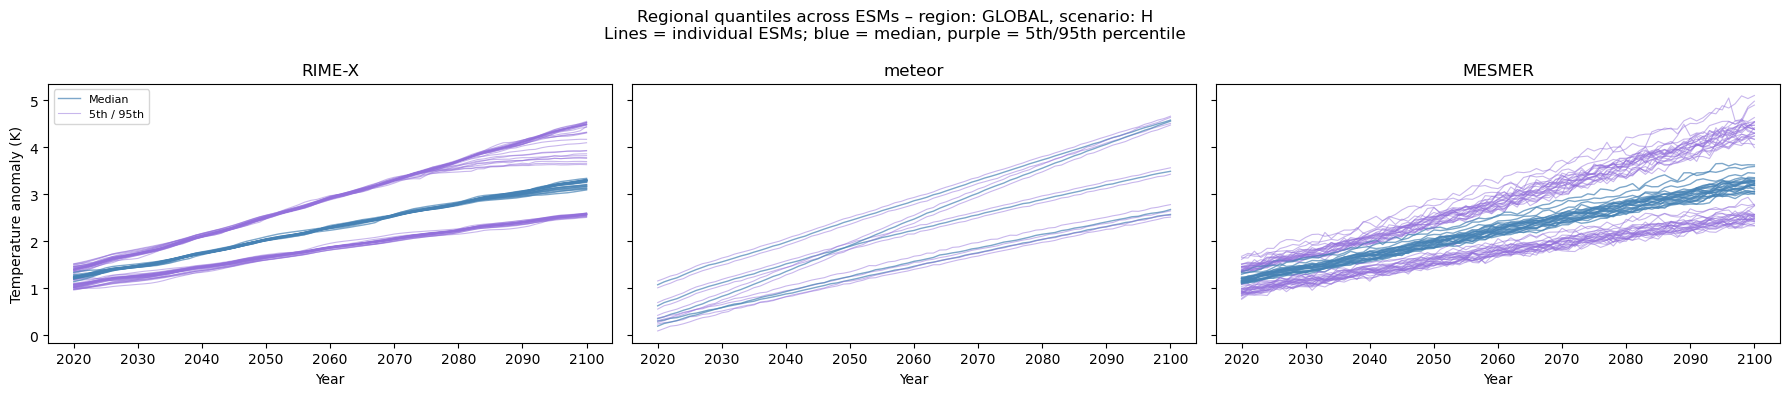

In [12]:
# Distribution of median, 5th and 95th percentiles across ESMs
# One line per ESM, no colour coding by ESM; median in blue, 5th/95th in purple

sel_mask = selected_regions[0]
region_name = _int_to_abbrev[sel_mask]

fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "regional", "quantiles-by-ESM")
    try:
        ds = filter_years(xr.open_dataset(f))
        yr = ds["year"].values
        esm_vals = ds[m["esm_dim"]].values

        for i, esm in enumerate(esm_vals):
            kw = {m["region_dim"]: m["region_vals"][sel_mask], m["esm_dim"]: esm}
            label_med = "Median" if i == 0 else None
            label_pct = "5th / 95th" if i == 0 else None
            median = sel1d(ds["tas"], model=m, quantile=0.5, **kw)
            lo     = sel1d(ds["tas"], model=m, quantile=0.05, **kw)
            hi     = sel1d(ds["tas"], model=m, quantile=0.95, **kw)
            ax.plot(yr, median, color="steelblue",  lw=1.0, alpha=0.7, label=label_med)
            ax.plot(yr, lo,     color="mediumpurple", lw=0.8, alpha=0.5, label=label_pct)
            ax.plot(yr, hi,     color="mediumpurple", lw=0.8, alpha=0.5)

        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Temperature anomaly (K)")
axes[0].legend(fontsize=8)
fig.suptitle(
    f"Regional quantiles across ESMs – region: {region_name}, scenario: {sel_scenario}\n"
    f"Lines = individual ESMs; blue = median, purple = 5th/95th percentile",
    fontsize=12
)
plt.tight_layout()
plt.show()

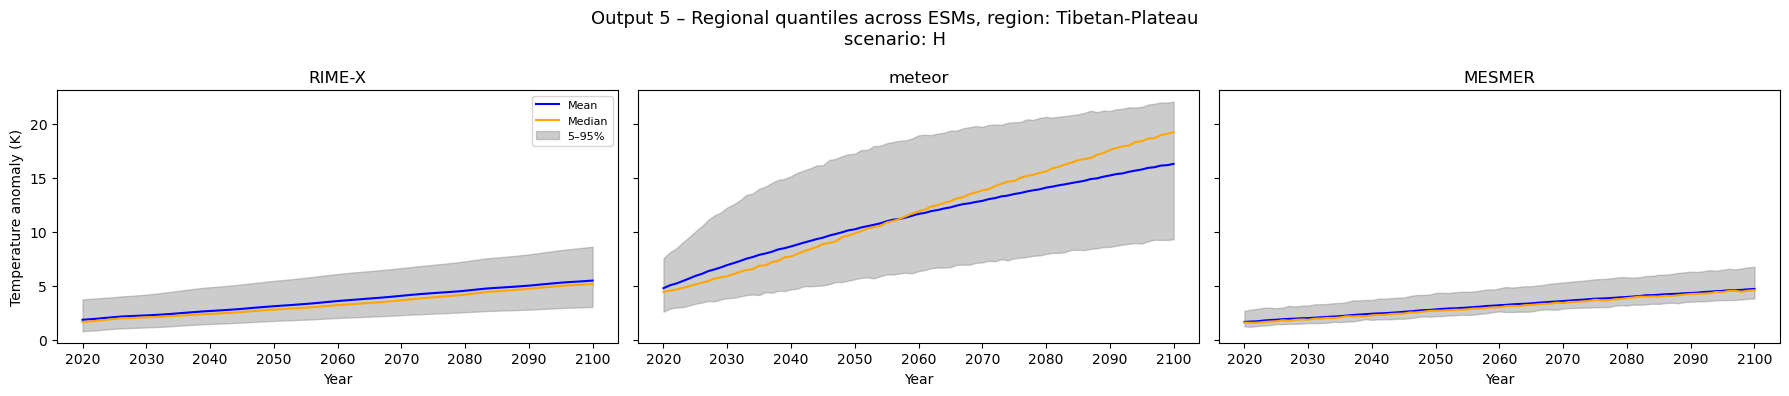

In [14]:
sel_mask = selected_regions[1]
region_name = regionmask.defined_regions.ar6.land[sel_mask].name

fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "regional", "quantiles-across-ESM")
    try:
        ds = filter_years(xr.open_dataset(f))
        kw = {m["region_dim"]: m["region_vals"][sel_mask]}
        mean   = sel1d(ds["tas_mean"], model=m, **kw)
        median = sel1d(ds["tas"], model=m, quantile=0.5, **kw)
        lo     = sel1d(ds["tas"], model=m, quantile=0.05, **kw)
        hi     = sel1d(ds["tas"], model=m, quantile=0.95, **kw)
        yr     = ds["year"].values
        ax.plot(yr, mean,   color="blue",   label="Mean")
        ax.plot(yr, median, color="orange", label="Median")
        ax.fill_between(yr, lo, hi, color="gray", alpha=0.4, label="5–95%")
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Temperature anomaly (K)")
axes[0].legend(fontsize=8)
fig.suptitle(
    f"Output 5 – Regional quantiles across ESMs, region: {region_name}\n"
    f"scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()


## 6a. Cross-scenario regional uncertainty

/tmp/ipykernel_69173/2367914509.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=7, loc="lower right")


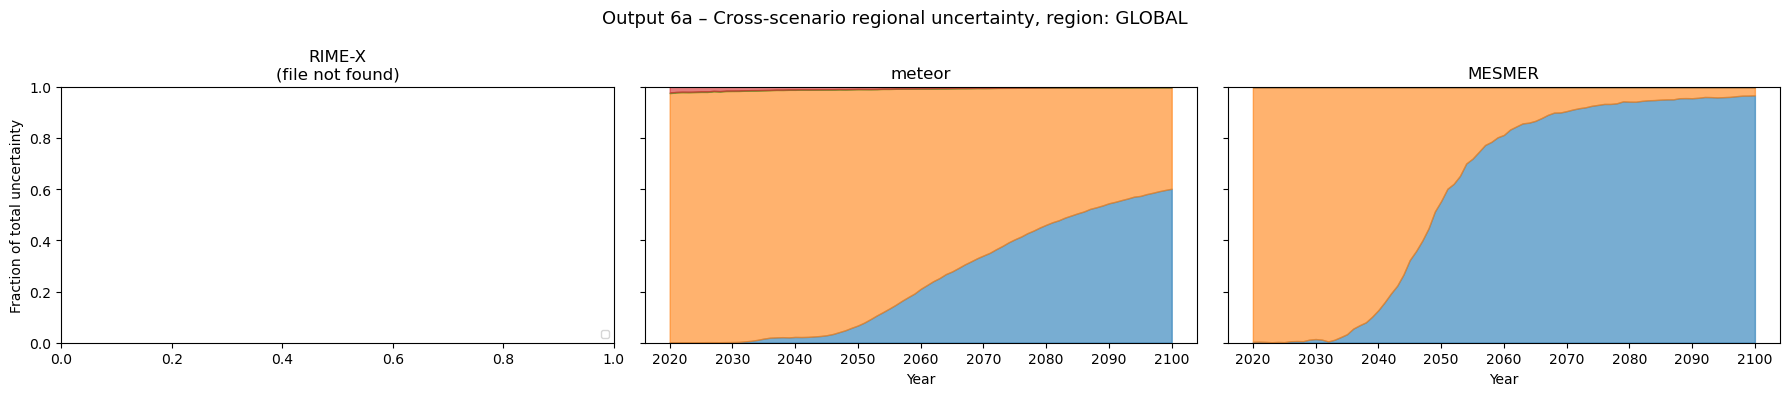

/tmp/ipykernel_69173/2367914509.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=7, loc="lower right")


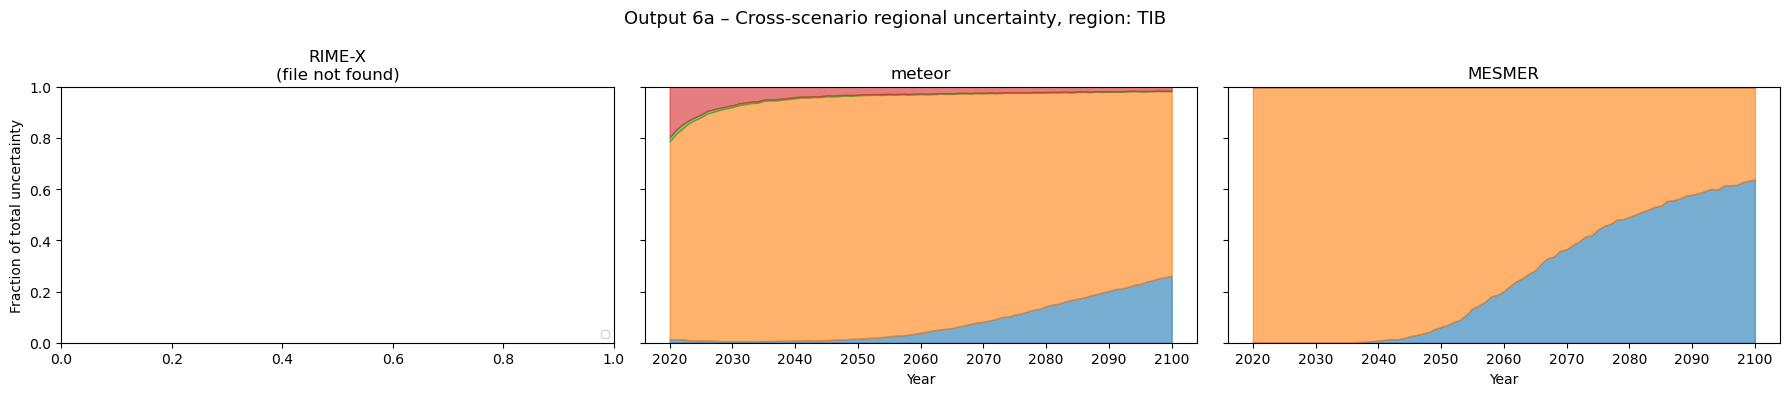

/tmp/ipykernel_69173/2367914509.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=7, loc="lower right")


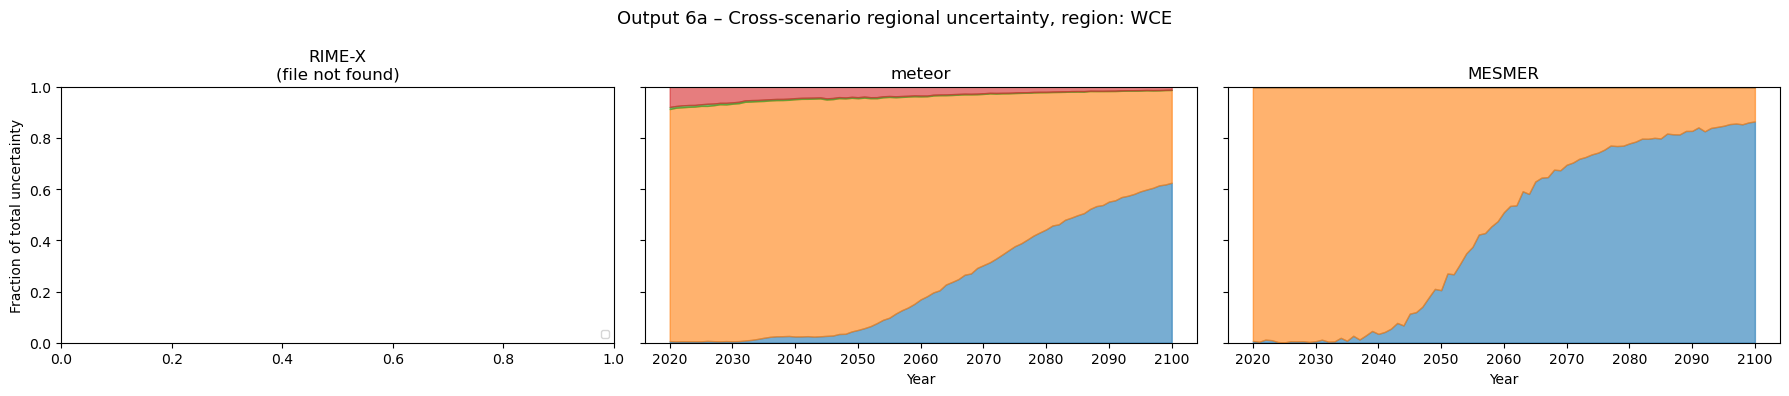

In [15]:
def plot_regional_uncertainty(ax, m, ds, sel_region, include_scenario=True, title=""):
    var_total = ds["var_scenario"] + ds["var_esm"] + ds[m['var_glob']] + ds["var_int"] \
        if include_scenario else ds["var_esm"] + ds[m['var_glob']] + ds["var_int"]
    yr = ds["year"].values
    base = np.zeros(len(yr))
    colors = ["C0", "C1", "C2", "C3"]
    labels = ["Scenario", "ESM", "Global response", "Internal var."]
    keys   = (["var_scenario"] if include_scenario else []) + ["var_esm", m['var_glob'], "var_int"]
    c_iter = iter(colors if include_scenario else colors[1:])
    l_iter = iter(labels if include_scenario else labels[1:])
    for k in keys:
        frac = (ds[k].sel({m["region_dim"]: m["region_vals"][sel_region]}) / var_total.sel({m["region_dim"]: m["region_vals"][sel_region]})).values
        top = base + frac
        ax.fill_between(yr, base, top, alpha=0.6, color=next(c_iter), label=next(l_iter))
        base = top
    ax.set_ylim(0, 1)
    ax.set_xlabel("Year")
    ax.set_title(title)

for sel_region in selected_regions:
    rname = _int_to_abbrev[sel_region]
    fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)
    for ax, m in zip(axes, MODELS):
        f = m["base_path"](m["root"]) / cross_fname(m["name"], "regional", "across-scenario-uncertainty")
        try:
            ds = filter_years(xr.open_dataset(f))
            ds["var_total"] = ds["var_scenario"] + ds["var_esm"] + ds[m['var_glob']] + ds["var_int"]
            plot_regional_uncertainty(ax, m, ds, sel_region, include_scenario=True, title=m["name"])
        except FileNotFoundError:
            ax.set_title(f"{m['name']}\n(file not found)")
    axes[0].set_ylabel("Fraction of total uncertainty")
    axes[0].legend(fontsize=7, loc="lower right")
    fig.suptitle(
        f"Output 6a – Cross-scenario regional uncertainty, region: {rname}",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

## 6b. Per-scenario regional uncertainty

/tmp/ipykernel_69173/76445460.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8, loc="lower right")


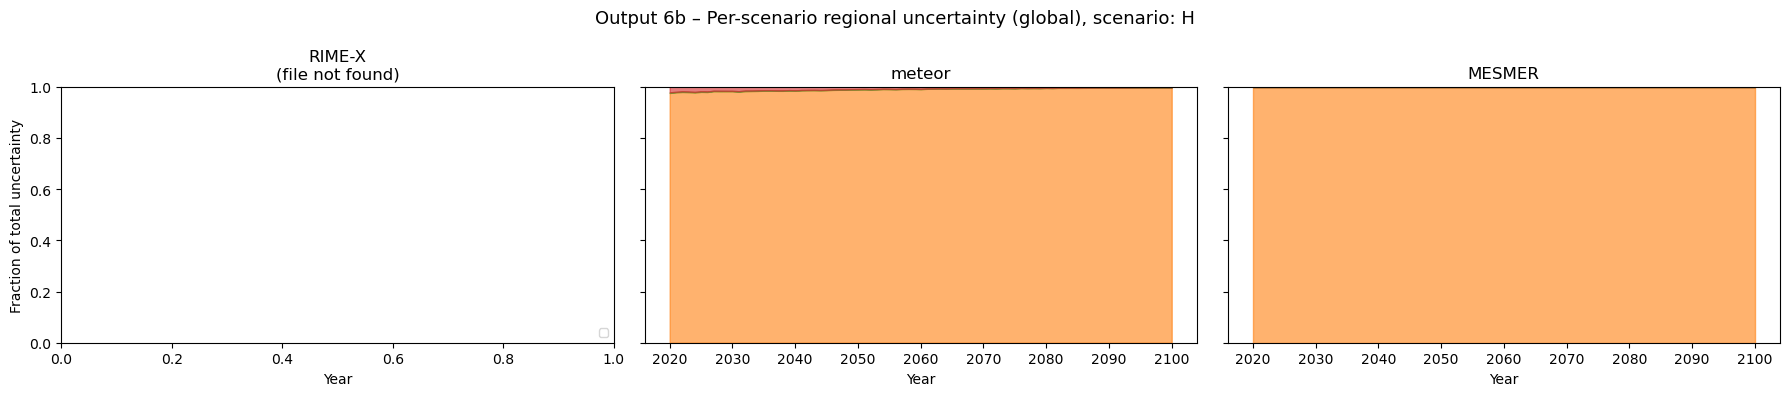

In [16]:
sel_region = -1  # global
fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "regional", "uncertainty")
    try:
        ds = filter_years(xr.open_dataset(f))
        yr = ds["year"].values
        var_total = ds["var_esm"] + ds[m["var_glob"]] + ds["var_int"]
        base = np.zeros(len(yr))
        for k, color, label in [
            ("var_esm",  "C1", "ESM"),
            (m["var_glob"], "C2", "Global response"),
            ("var_int",  "C3", "Internal var."),
        ]:
            frac = (ds[k].sel(mask=sel_region) / var_total.sel(mask=sel_region)).values
            ax.fill_between(yr, base, base + frac, alpha=0.6, color=color, label=label)
            base = base + frac
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Fraction of total uncertainty")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(
    f"Output 6b – Per-scenario regional uncertainty (global), scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()


## 7a. Cross-scenario gridcell uncertainty

/tmp/ipykernel_69173/553261272.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8, loc="upper left")


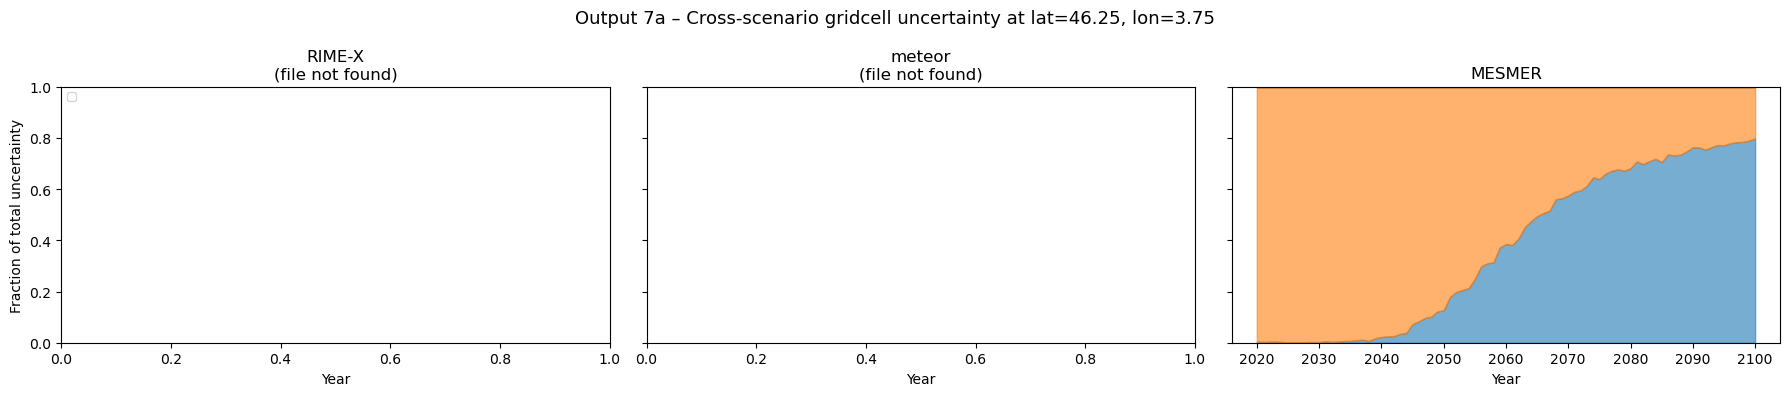

In [17]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    f = m["root"] / cross_fname(m["name"], "gridcell", "across-scenario-uncertainty")
    try:
        ds = filter_years(xr.open_dataset(f))
        ds["var_total"] = ds["var_scenario"] + ds["var_esm"] + ds[m["var_glob"]] + ds["var_int"]
        yr = ds["year"].values
        base = np.zeros(len(yr))
        var_total = ds["var_total"].sel(lat=sel_lat, lon=sel_lon).values
        for k, color, label in [
            ("var_scenario", "C0", "Scenario"),
            ("var_esm",      "C1", "ESM"),
            (m["var_glob"],     "C2", "Global response"),
            ("var_int",      "C3", "Internal var."),
        ]:
            frac = ds[k].sel(lat=sel_lat, lon=sel_lon).values / var_total
            ax.fill_between(yr, base, base + frac, alpha=0.6, color=color, label=label)
            base = base + frac
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Fraction of total uncertainty")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle(
    f"Output 7a – Cross-scenario gridcell uncertainty at lat={sel_lat}, lon={sel_lon}",
    fontsize=13
)
plt.tight_layout()
plt.show()


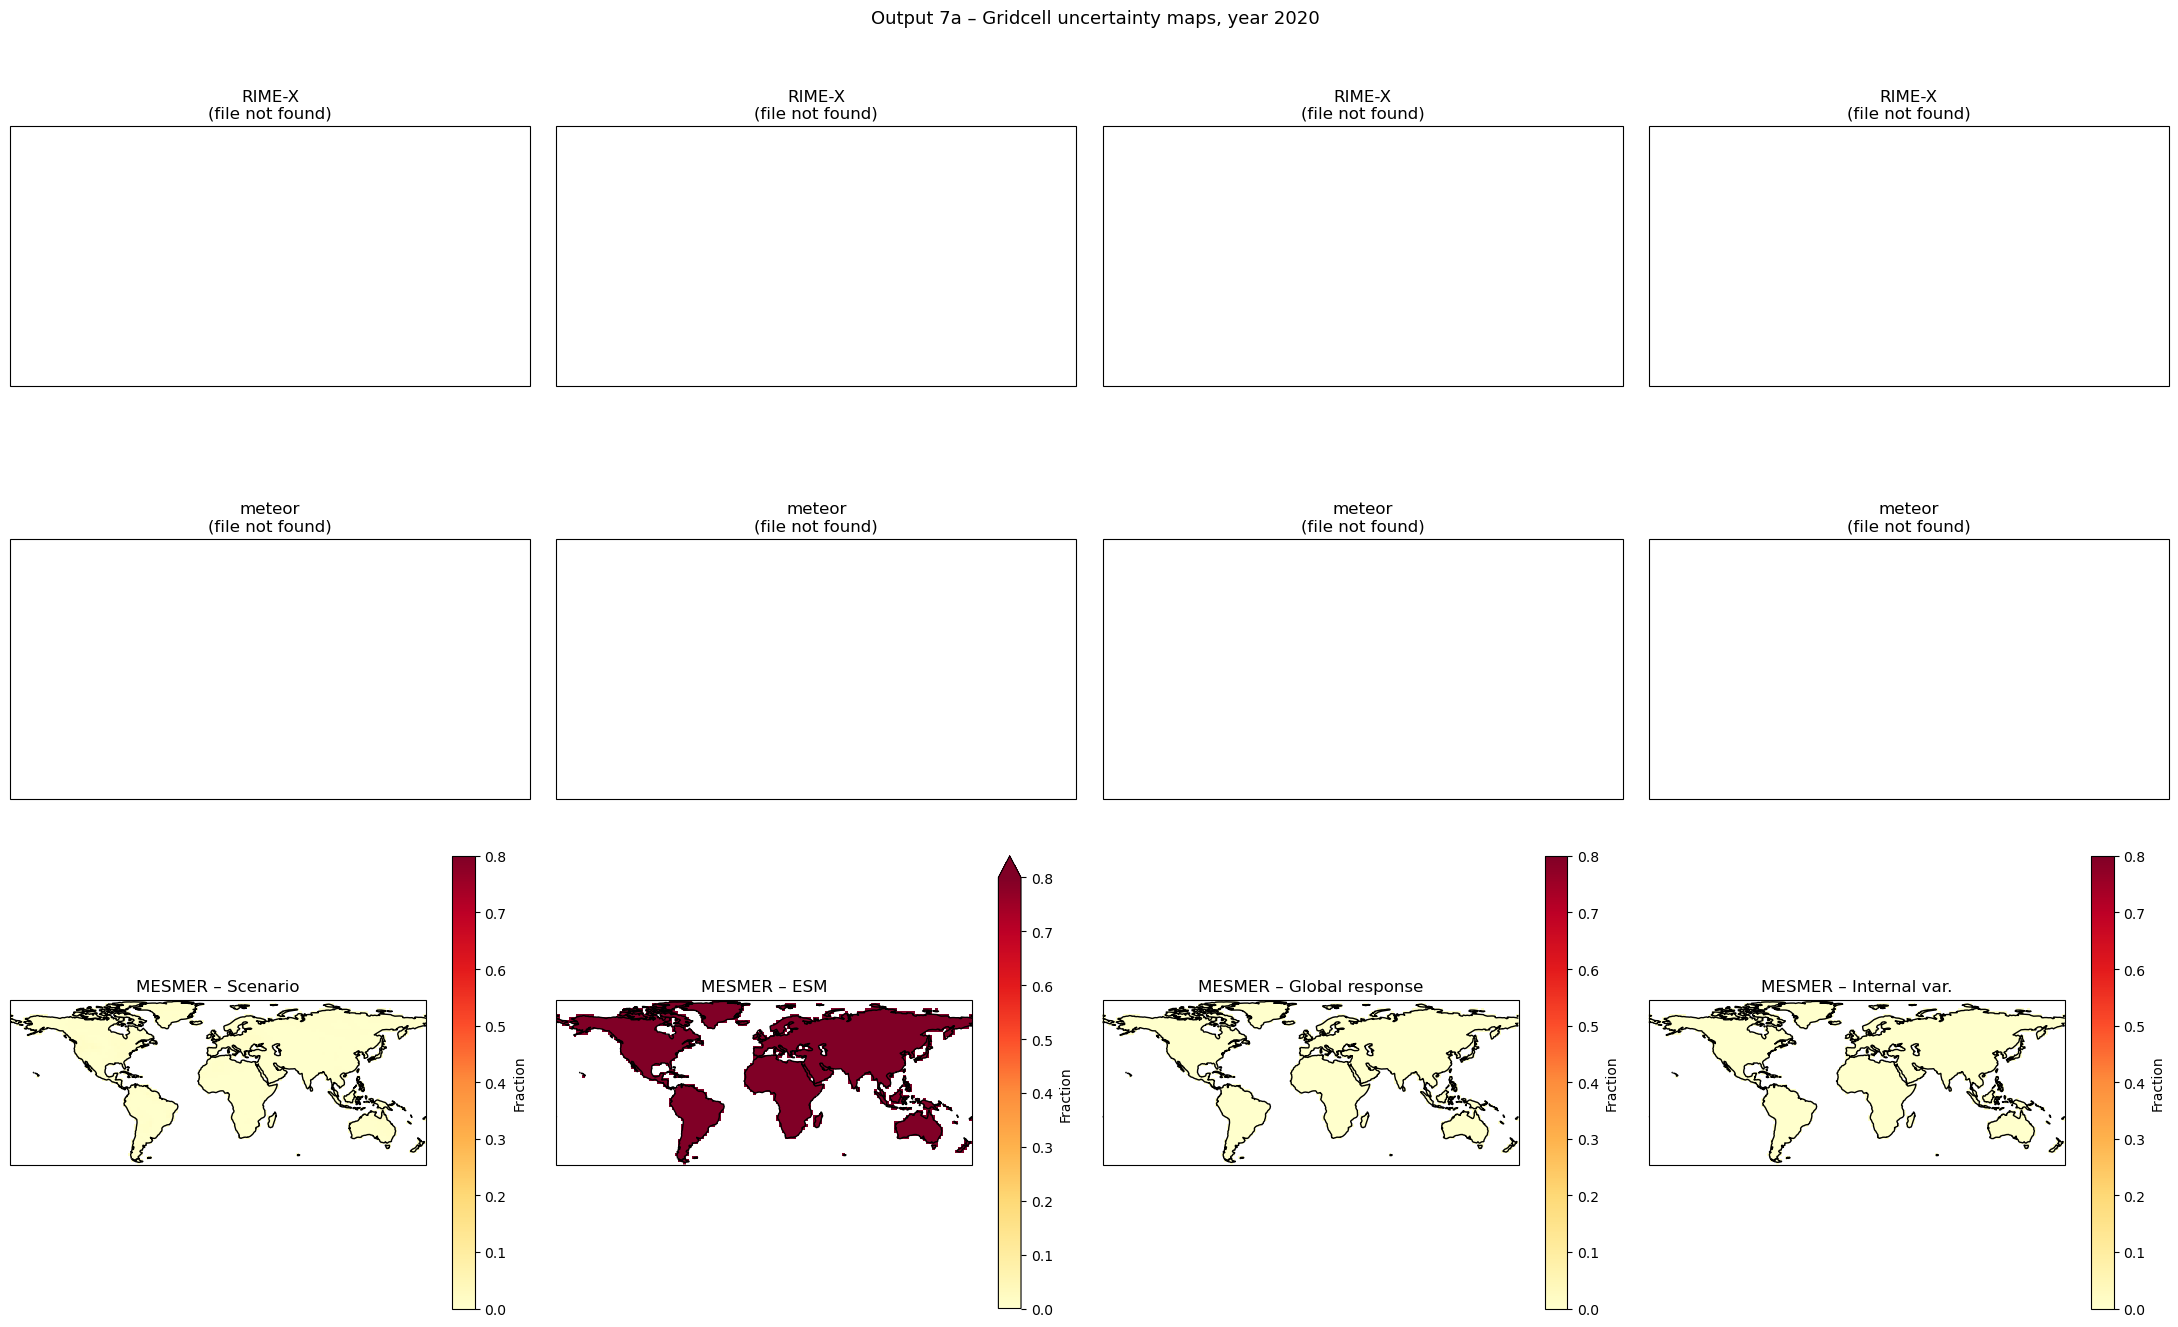

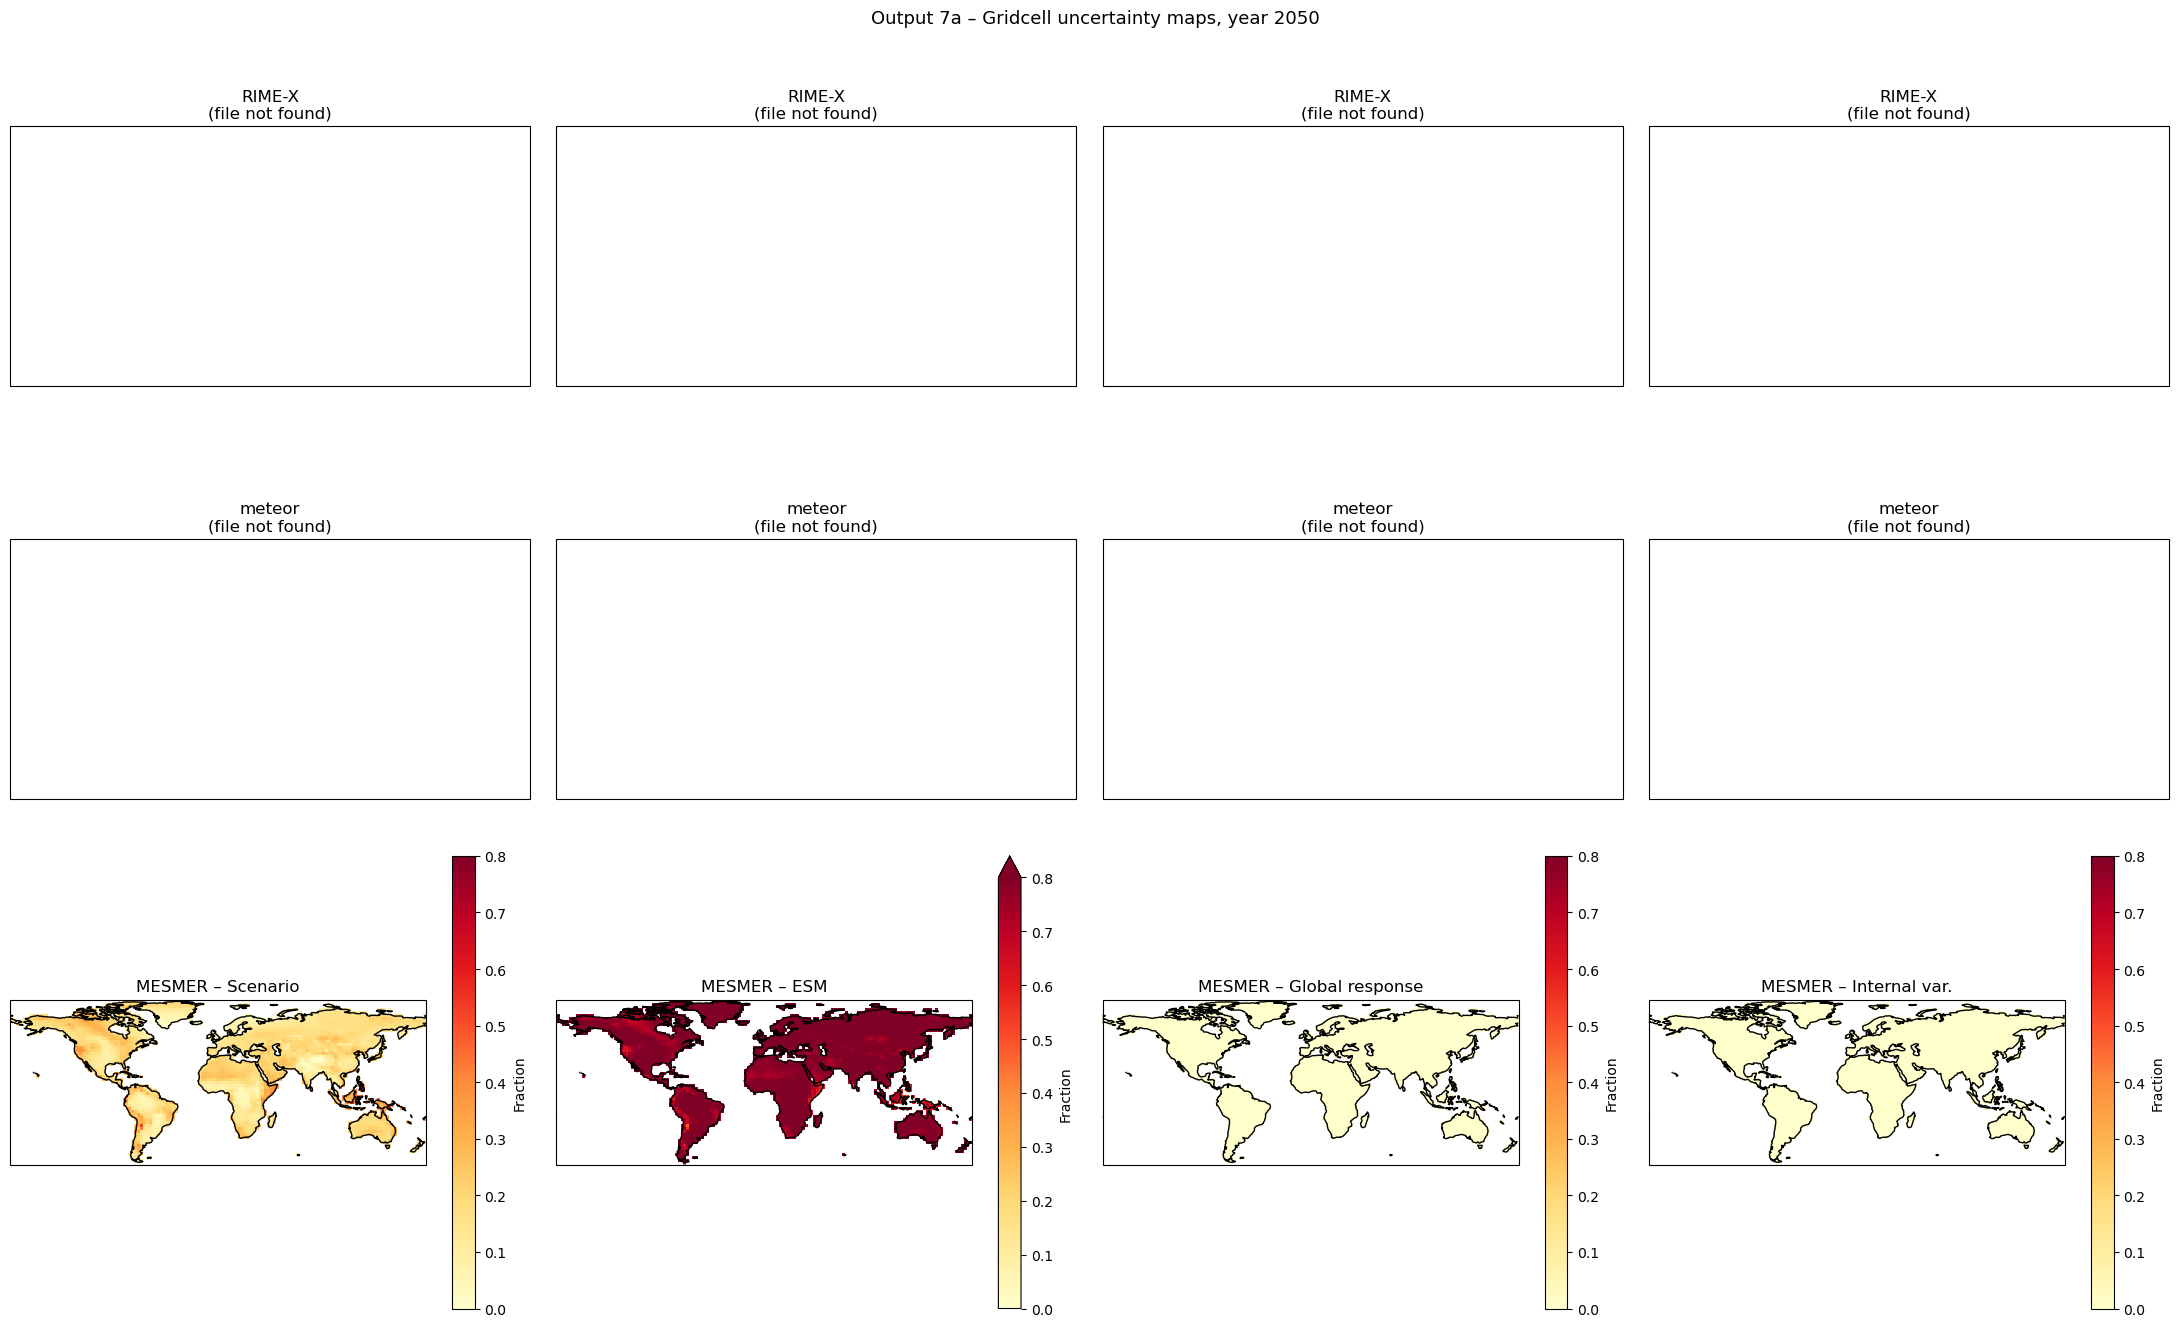

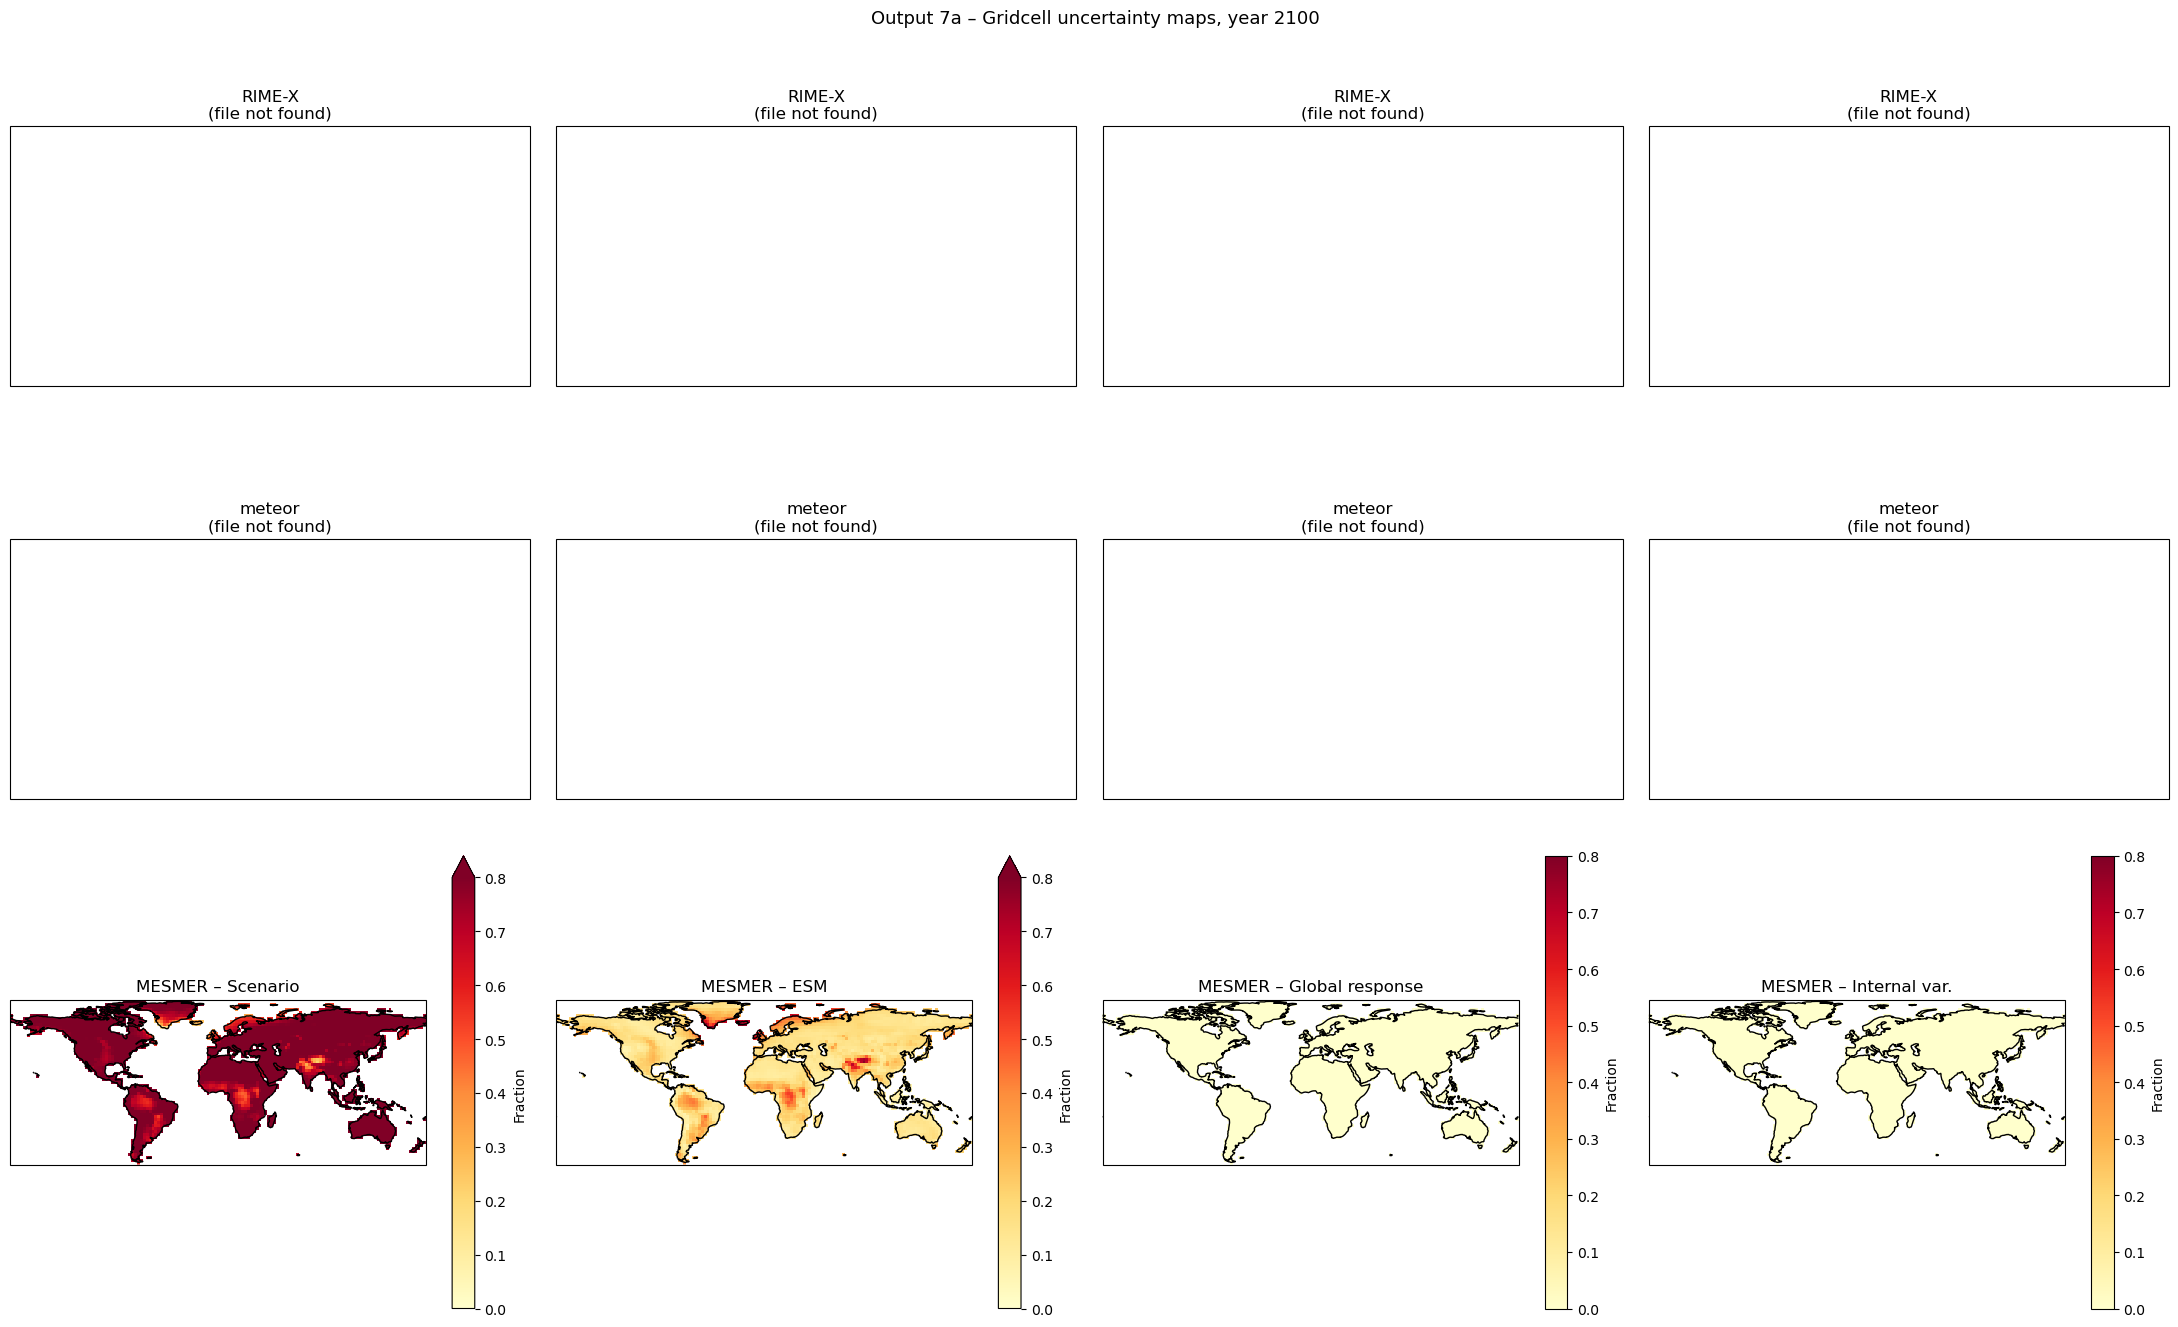

In [18]:
for sel_year in [2020, 2050, 2100]:
    fig, axes = plt.subplots(
        len(MODELS), 4,
        figsize=(22, 4.5 * len(MODELS)),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )
    unc_vars = ["var_scenario", "var_esm", "var_glob", "var_int"]
    utitles  = ["Scenario", "ESM", "Global response", "Internal var."]

    for row, m in enumerate(MODELS):
        f = m["root"] / cross_fname(m["name"], "gridcell", "across-scenario-uncertainty")
        try:
            ds = filter_years(xr.open_dataset(f))
            ds["var_total"] = sum(ds[v] for v in unc_vars)
            for col, (v, ut) in enumerate(zip(unc_vars, utitles)):
                ax = axes[row, col]
                frac = (ds[v].sel(year=sel_year) / ds["var_total"].sel(year=sel_year))
                frac.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="YlOrRd",
                          vmin=0, vmax=0.8, cbar_kwargs={"label": "Fraction"})
                ax.coastlines()
                ax.set_title(f"{m['name']} – {ut}")
        except FileNotFoundError:
            for col in range(4):
                axes[row, col].set_title(f"{m['name']}\n(file not found)")

    fig.suptitle(f"Output 7a – Gridcell uncertainty maps, year {sel_year}", fontsize=13)
    plt.tight_layout()
    plt.show()


## 7b. Per-scenario gridcell uncertainty

/tmp/ipykernel_69173/2252254986.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8, loc="lower right")


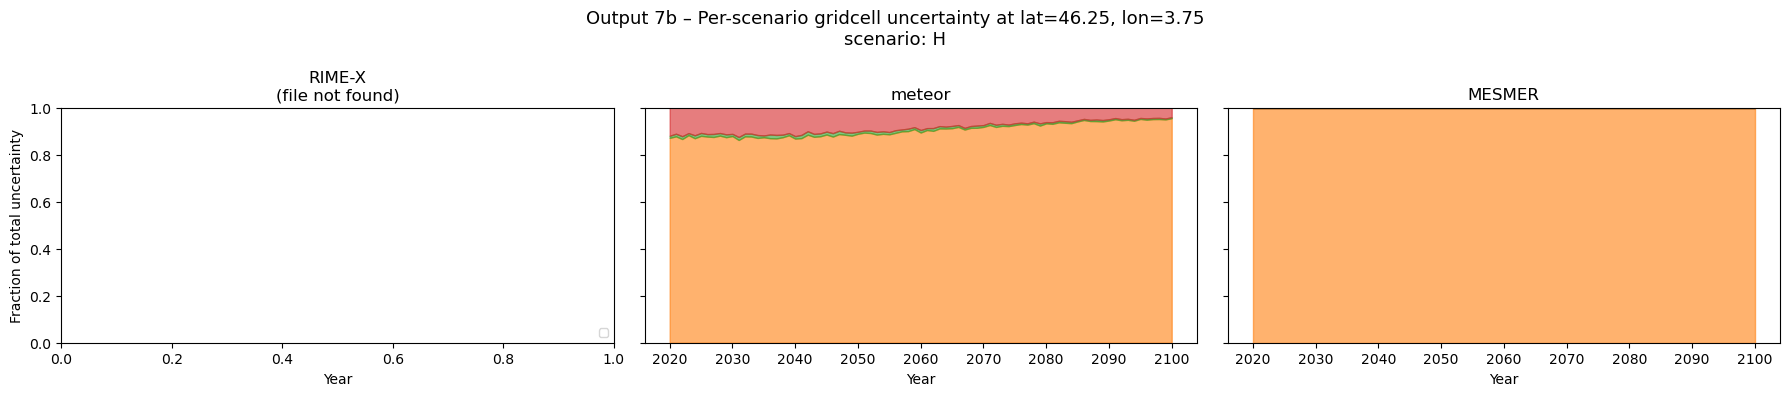

In [19]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(6*len(MODELS), 4), sharey=True)

for ax, m in zip(axes, MODELS):
    path = model_path(m, sel_scenario)
    f = path / fname(file_scen_token(m, sel_scenario), m["name"], "gridcell", "uncertainty")
    try:
        ds = filter_years(xr.open_dataset(f))
        yr = ds["year"].values
        var_total = ds["var_esm"] + ds[m["var_glob"]] + ds["var_int"]
        base = np.zeros(len(yr))
        total_vals = var_total.sel(lat=sel_lat, lon=sel_lon).values
        for k, color, label in [
            ("var_esm",  "C1", "ESM"),
            (m["var_glob"], "C2", "Global response"),
            ("var_int",  "C3", "Internal var."),
        ]:
            frac = ds[k].sel(lat=sel_lat, lon=sel_lon).values / total_vals
            ax.fill_between(yr, base, base + frac, alpha=0.6, color=color, label=label)
            base = base + frac
        ax.set_title(m["name"])
    except FileNotFoundError:
        ax.set_title(f"{m['name']}\n(file not found)")
    ax.set_xlabel("Year")
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Fraction of total uncertainty")
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle(
    f"Output 7b – Per-scenario gridcell uncertainty at lat={sel_lat}, lon={sel_lon}\n"
    f"scenario: {sel_scenario}",
    fontsize=13
)
plt.tight_layout()
plt.show()
